# Does Andrews' pitchfork actually "channel" price? 🔱
### A famous chart tool — three dots, a median line, two tines — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Respects_the_fork%3F: Busted](https://img.shields.io/badge/Respects_the_fork%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find **Andrews' pitchfork**: click three swing points and it draws a three-pronged fork across the chart. The lore, taught by Alan Andrews himself and repeated on every chart-pattern site, is that **price respects the fork** — it rides between the outer prongs (the *tines*) and keeps getting pulled back to the middle prong (the *median line*). So when price drops to the **lower tine**, you buy: it's "supposed" to bounce.

It *looks* uncanny on a hand-picked chart. But a tool you draw **after** the move, by choosing which three dots to connect, is the textbook setup for fooling yourself. So we did the only fair thing: encode the fork **mechanically** (no eyeballing), fire the "buy the lower tine" rule thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from andrews_pitchfork import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real pitchfork cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 819, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 819, 39.0, 61, 3.81, 48.5, -9.5, 37.0, -0.73, 0.467), 'h10': (10, 818, 40.1, 60, 2.63, 65.6, -25.5, 38.1, -1.44, 0.15), 'h20': (20, 818, 92.2, 62, 3.93, 131.3, -39.1, 90.2, -1.61, 0.107), 'h60': (60, 811, 305.0, 70, 6.47, 232.1, 72.8, 303.0, 1.77, 0.078), 'per': [('SPY', 161, 51.7, 0.92, 132.9, -81.2), ('QQQ', 162, 134.7, 2.59, 182.2, -47.5), ('IWM', 159, 75.3, 1.27, 107.4, -32.1), ('DIA', 144, 110.0, 2.26, 92.8, 17.3), ('GLD', 193, 91.0, 2.12, 135.8, -44.9)], 'placebo': (51.7, 0.611, 500), 'syn': [(0.0, 111, -21.0, 48, -0.52), (0.4, 122, 110.9, 64, 3.44)]}


real pitchfork cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price touches the **lower tine**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60% and the returns look great. |
| Is that *the fork's* doing? | **No.** Buy on **random days** instead and you do **just as well or better**. The fork adds nothing — at 5/10/20 days the touch is actually *worse* than a coin-flip entry. |
| Does price "respect" the channel? | **Not in any usable way.** Scramble the fork's geometry into nonsense and the result barely changes. The lines aren't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a chart pattern. |

> The pitchfork is a great way to *describe* a trend after the fact. As a *forecast* — "the lower tine will bounce" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the fork.

## 1 · The claim

> *"Pick three swing points. The **median line** runs from the first through the middle of the other two; two parallel **tines** run through them. Price will oscillate inside the fork and keep returning to the median line. Buy the lower tine, sell the upper — price respects the channel."*

This is **Alan Andrews'** median-line method (1960s–70s), still taught today and built into TradingView, MetaTrader and every charting suite. Andrews claimed price reaches the median line **~80% of the time**. It's one of the most recognisable tools in technical analysis — so: does the channel actually *channel*?

## 2 · So what?

If the fork genuinely *forecast* reversals, it would be remarkable: three past dots would predict future turning points, a clean crack in market efficiency you could trade with a ruler. That's the dream the tool sells.

But there's a trap built into it. A pitchfork is drawn **by hand, after the swings have happened** — you choose the three dots that make the channel *look* right. And it's drawn on a market (stock indices) that drifts **up** over time, so *any* dip-buying rule will look profitable. To separate the **tool** from the **tide**, we have to (a) draw the fork by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **10 lower (higher) bars on each side** — a confirmed fractal. Crucially it's only known **10 bars later**, so we never draw the fork with future data.
2. **Draw the fork by rule.** At every bar, anchor it on the three most-recent confirmed pivots — no eyeballing, no cherry-picking which dots to connect.
3. **Trade the lore.** When the close drops **below the lower tine**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the fork matters, the tine-touch must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical fork even look like? Here's SPY with the fork drawn on its three most-recent confirmed pivots, and the lower-tine touches the rule would buy.

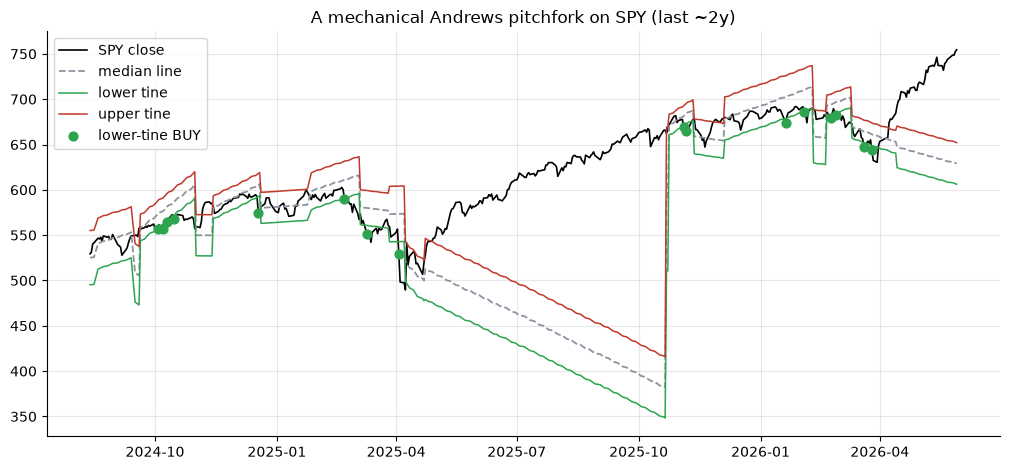

lower-tine touches in window: 16


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    med, low, up = st.build_forks(cl, k=R['k'])
    ent = st.tine_touch_entries(cl, k=R['k'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, med.reindex(seg.index), c=GREY, lw=1.3, ls='--', label='median line')
    ax.plot(seg.index, low.reindex(seg.index), c=GREEN, lw=1.1, label='lower tine')
    ax.plot(seg.index, up.reindex(seg.index), c=RED, lw=1.1, label='upper tine')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=40, zorder=5, label='lower-tine BUY')
    ax.set_title('A mechanical Andrews pitchfork on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('lower-tine touches in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The fork tracks the trend nicely — *as a description*. The question is whether those green buy dots are followed by bounces. **Let's race the tine-touch against random entries** at four horizons. Blue = buy the lower tine; grey = buy on random days.

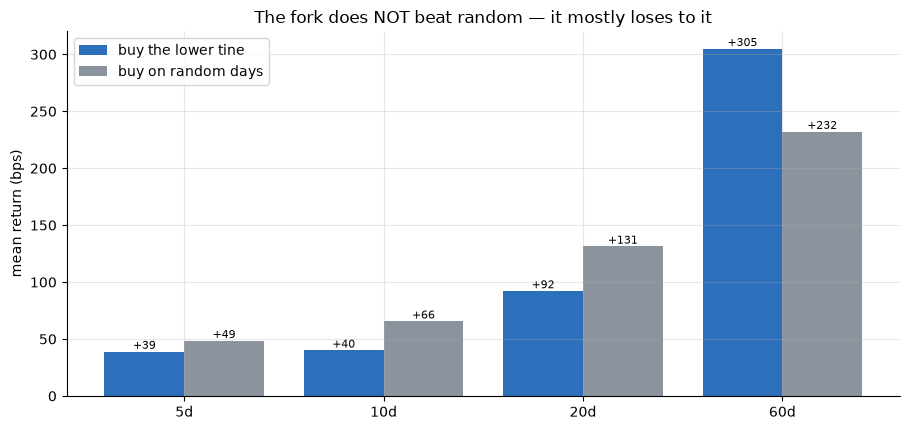

touch: [39, 40, 92, 305]
random: [49, 66, 131, 232]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    touch, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.tine_touch_entries(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        touch.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    touch = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, touch, .4, color='#2c6fbb', label='buy the lower tine')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(touch,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The fork does NOT beat random — it mostly loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('touch:', [round(v) for v in touch]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The tine-touch makes money in absolute terms (**+92 bps** over 20 days) — but **random entries make more** (**+131 bps**). At 5, 10 and 20 days the famous fork is *worse* than throwing darts. Only at 60 days does it nose ahead, and even then not by a statistically meaningful margin (the quants notebook shows the *t* never clears 2). The apparent edge was **the market's upward drift**, not the lines.

**One more sanity check.** What if we scramble the fork's *geometry* — keep the same pivot dates but shuffle which price sits where, so the lines become nonsense? If price really 'respects the fork', the nonsense fork should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_draws=300, seed=450)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real fork lower-tine touch (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-geometry* forks do at least as well (p={pval:.2f}).')
print('=> the geometry is not doing the work.')

real fork lower-tine touch (SPY, 20d): +51.7 bps
... but 61% of *scrambled-geometry* forks do at least as well (p=0.61).
=> the geometry is not doing the work.


More than half of the **scrambled** forks match or beat the real one (*p* = 0.61). If price genuinely respected *these specific lines*, a random scramble would collapse the result. It doesn't — because the result was never about the lines.

## 5 · The verdict

- **Signal — None.** The lower-tine buy does **not** beat buying on random days (it's *worse* at 5–20 days; the touch-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the fork.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Price respects the fork"? — Busted.** Scramble the geometry into nonsense and the result barely moves. The channel doesn't channel.

## 6 · Could you actually trade it?

There's nothing here to trade. The tine-touch's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The pitchfork buy is a worse, more expensive way to be long. Costs (commissions + spread on every touch) push the already-no-edge result further negative. As a forecasting tool, it doesn't pay; as a drawing tool, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The median-line target.** Andrews' stronger claim is that price reaches the *median line* ~80% of the time. That's nearly tautological for a trending series (the median line *is* a smoothed trend) — a fun follow-up is to show the 80% holds for a random walk too.
- **Different pivot rules.** Try a wider/narrower fractal window, or hand-anchored Andrews forks — the result is robust: drift in, fork out.
- **A real positive control.** The quants notebook plants a *genuine* tine-bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the fork forecasts? Show the lower-tine touch beating random entries at **t ≥ 2** on a real tape — then we'll talk.*